In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from tqdm import tqdm
import re
import ast


from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix,
                             classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)

import torch
from torch.utils.data import Dataset, DataLoader
from IPython.utils.sysinfo import encoding

from transformers import AutoTokenizer, AutoModelForSequenceClassification

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Загрузка

In [ ]:
data = pd.read_csv('/content/data_no_keywords.csv')

In [ ]:
print(f"Всего статей: {len(data)}")
print(f"Тематик: {data['category'].nunique()}")
print("Тематики и количество статей")
data['category'].value_counts()

Всего статей: 13238
Тематик: 10
Тематики и количество статей


,count
category,
Бэкенд,1796
AI и ML,1781
Научпоп,1651
Менеджмент,1541
Администрирование,1483
Информационная безопасность,1468
Фронтенд,1053
Маркетинг и контент,937
Геймдев,934


## Обработка

In [ ]:
def data_prep(text, title, topics):
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"http\S+", " ", text)
    text = text.replace("\xa0", " ")
    text = re.sub(r"\s+", " ", text).strip()

    if isinstance(topics, str):
        topics = ast.literal_eval(topics)

    cleaned_topics = [topic.replace(" ", "") for topic in topics]
    topics_str = " ".join(cleaned_topics)

    final_text = f'{title} [SEP] {topics_str} [SEP] {text}'
    return final_text

In [ ]:
data['full_text'] = data.apply(lambda x: data_prep(x['full_text'], x['title'], x['topics']), axis=1)

In [ ]:
train_df, test_df = train_test_split(data, test_size=0.1, random_state=42, stratify=data['category'])

## Создание датасета

In [ ]:
class HabrDataset(Dataset):
  def __init__(self, text, labels, tokenizer, max_len=256):
    self.text = text
    self.labels = labels
    self.tokenizer = tokenizer
    self.max_len = max_len

  def __len__(self):
    return len(self.text)

  def __getitem__(self, idx):
    text = str(self.text[idx])
    label = self.labels[idx]

    encoding = self.tokenizer(
      text,
      padding='max_length',
      truncation=True,
      max_length=self.max_len,
      return_tensors='pt'
    )

    return {
      'input_ids': encoding['input_ids'].flatten(),
      'attention_mask': encoding['attention_mask'].flatten(),
      'labels': torch.tensor(label, dtype=torch.long)
    }

In [ ]:
def creating_dataloader(tokenizer, batch_size = 16, max_len=256):
  train_dataset = HabrDataset(train_texts, train_labels, tokenizer, max_len)
  test_dataset = HabrDataset(test_texts, test_labels, tokenizer, max_len)

  train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2
  )

  val_loader = DataLoader(
      test_dataset,
      batch_size=batch_size,
      shuffle=False,
      num_workers=2
  )
  return train_loader, val_loader

In [ ]:
label_names = sorted(train_df['category'].unique())
num_labels = len(label_names)

label_to_id = {label: i for i, label in enumerate(label_names)}
id_to_label = {i: label for label, i in label_to_id.items()}

train_texts = train_df['full_text'].tolist()
train_labels = [label_to_id[label] for label in train_df['category']]

test_texts = test_df['full_text'].tolist()
test_labels = [label_to_id[label] for label in test_df['category']]

## Training Loop

In [ ]:
class Triner:
    def __init__(self, model, optimizer, train_loader, val_loader,
      device, scheduler=None, label_names=None, save_path='best_model.pt',
      patience=3, delta=1e-4):

      self.model = model
      self.optimizer = optimizer
      self.train_loader = train_loader
      self.val_loader = val_loader
      self.device = device
      self.scheduler = scheduler
      self.label_names = label_names
      self.save_path = save_path

      self.patience = patience
      self.delta = delta
      self.early_stop_counter = 0

      self.model.to(device)

      self.f1_best = 0
      self.results = {
          "train_loss": [],
          "val_loss": [],
          "val_acc": [],
          "train_f1": [],
          "val_f1": []
      }

      self.best_labels = None
      self.best_preds = None
      self.last_labels = None
      self.last_preds = None

    def train_epoch(self):
      self.model.train()
      total_loss = 0

      for batch in tqdm(self.train_loader):
          batch = {k: v.to(self.device) for k, v in batch.items()}

          self.optimizer.zero_grad()

          outputs = self.model(**batch)
          loss = outputs.loss
          loss.backward()

          self.optimizer.step()
          if self.scheduler:
              self.scheduler.step()

          total_loss += loss.item()

      return total_loss / len(self.train_loader)

    def eval_epoch(self):
      self.model.eval()
      total_loss = 0
      all_preds, all_labels = [], []

      for batch in tqdm(self.val_loader):
          batch = {k: v.to(self.device) for k, v in batch.items()}

          with torch.no_grad():
              outputs = self.model(**batch)

          loss = outputs.loss
          logits = outputs.logits
          predictions = torch.argmax(logits, dim=-1)

          total_loss += loss.item()
          all_preds.extend(predictions.cpu().numpy())
          all_labels.extend(batch['labels'].cpu().numpy())

      acc = accuracy_score(all_labels, all_preds)
      f1 = f1_score(all_labels, all_preds, average='macro')

      self.last_labels = np.array(all_labels)
      self.last_preds = np.array(all_preds)

      return total_loss / len(self.val_loader), acc, f1

    def get_train_f1(self):
      self.model.eval()
      all_preds, all_labels = [], []

      for batch in tqdm(self.train_loader, desc="Computing train F1"):
          batch = {k: v.to(self.device) for k, v in batch.items()}

          with torch.no_grad():
              outputs = self.model(**batch)

          logits = outputs.logits
          predictions = torch.argmax(logits, dim=-1)

          all_preds.extend(predictions.cpu().numpy())
          all_labels.extend(batch['labels'].cpu().numpy())

      return f1_score(all_labels, all_preds, average='macro')

    def fit(self, epochs):
      for epoch in range(epochs):
          print(f'\nEpoch {epoch + 1}/{epochs}')

          train_loss = self.train_epoch()
          val_loss, acc_val, f1_val = self.eval_epoch()
          train_f1 = self.get_train_f1()

          self.results["train_loss"].append(train_loss)
          self.results["val_loss"].append(val_loss)
          self.results["val_acc"].append(acc_val)
          self.results["train_f1"].append(train_f1)
          self.results["val_f1"].append(f1_val)

          print(
              f"Train loss: {train_loss:.4f} | "
              f"Val loss: {val_loss:.4f} | "
              f"Accuracy: {acc_val:.4f} | "
              f"Train F1: {train_f1:.4f} | "
              f"Val F1: {f1_val:.4f}"
          )

          if f1_val > self.f1_best + self.delta:
              self.f1_best = f1_val
              self.early_stop_counter = 0

              self.best_labels = self.last_labels.copy()
              self.best_preds = self.last_preds.copy()

              model_filename = f'{f1_val:.4f}_{self.save_path}'

              torch.save(self.model.state_dict(), model_filename)
              print("Best model saved")

          else:
              self.early_stop_counter += 1
              if self.early_stop_counter >= self.patience:
                print("Early stopping")
                break

      print("\nTraining finished")

    def plot_history(self):
      epochs = range(1, len(self.results["train_loss"]) + 1)

      plt.figure(figsize=(14,5))

      plt.subplot(1,2,1)
      plt.plot(epochs, self.results["train_loss"], marker="o", label="Train loss")
      plt.plot(epochs, self.results["val_loss"], marker="o", label="Val loss")
      plt.title("Loss")
      plt.xlabel("Epoch")
      plt.ylabel("Loss")
      plt.legend()
      plt.grid()

      plt.subplot(1,2,2)
      plt.plot(epochs, self.results["train_f1"], marker="o", label="Train F1")
      plt.plot(epochs, self.results["val_f1"], marker="o", label="Validation F1")
      plt.title("F1 Score")
      plt.xlabel("Epoch")
      plt.ylabel("F1 Score")
      plt.legend()
      plt.grid()

      plt.show()

    def classification_report(self):
      print("\nClassification report:\n")
      print(classification_report(self.best_labels, self.best_preds, target_names=self.label_names))

      cm = confusion_matrix(self.best_labels, self.best_preds)

      plt.figure(figsize=(12,12))
      disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=self.label_names)
      disp.plot(xticks_rotation=90, cmap="Blues", values_format="d")
      plt.title("Confusion Matrix")
      plt.show()

# DeepPavlov/rubert-base-cased

In [ ]:
rubert_model_name = "DeepPavlov/rubert-base-cased"
tokenizer = AutoTokenizer.from_pretrained(rubert_model_name)

model_bert = AutoModelForSequenceClassification.from_pretrained(
    rubert_model_name,
    num_labels=num_labels
)

config.json:   0%|          | 0.00/642 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/24.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/714M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: DeepPavlov/rubert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you

## max_len = 256

In [ ]:
train_loader, val_loader = creating_dataloader(tokenizer, 16)
optimizer = torch.optim.AdamW(model_bert.parameters(), lr=2e-5)

In [ ]:
trainer = Triner(
    model=model_bert,
    optimizer=optimizer,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    scheduler=None,
    label_names=label_names,
    save_path="best_model_BERT_256.pt"
)

trainer.fit(epochs=5)


Epoch 1/5


Computing train F1: 100%|██████████| 745/745 [02:57<00:00,  4.19it/s]


Train loss: 0.8645 | Val loss: 0.6641 | Accuracy: 0.7998 | Train F1: 0.8547 | Val F1: 0.8068
Best model saved

Epoch 2/5


Computing train F1: 100%|██████████| 745/745 [02:56<00:00,  4.22it/s]


Train loss: 0.5290 | Val loss: 0.6274 | Accuracy: 0.8066 | Train F1: 0.9031 | Val F1: 0.8124
Best model saved

Epoch 3/5


...

Train loss: 0.3766 | Val loss: 0.7163 | Accuracy: 0.7915 | Train F1: 0.9183 | Val F1: 0.7991

Epoch 4/5


Computing train F1: 100%|██████████| 745/745 [02:57<00:00,  4.21it/s]


Train loss: 0.2355 | Val loss: 0.7384 | Accuracy: 0.7938 | Train F1: 0.9723 | Val F1: 0.8052

Epoch 5/5


Computing train F1: 100%|██████████| 745/745 [02:55<00:00,  4.25it/s]


Train loss: 0.1342 | Val loss: 0.8463 | Accuracy: 0.7870 | Train F1: 0.9830 | Val F1: 0.7935
Early stopping

Training finished


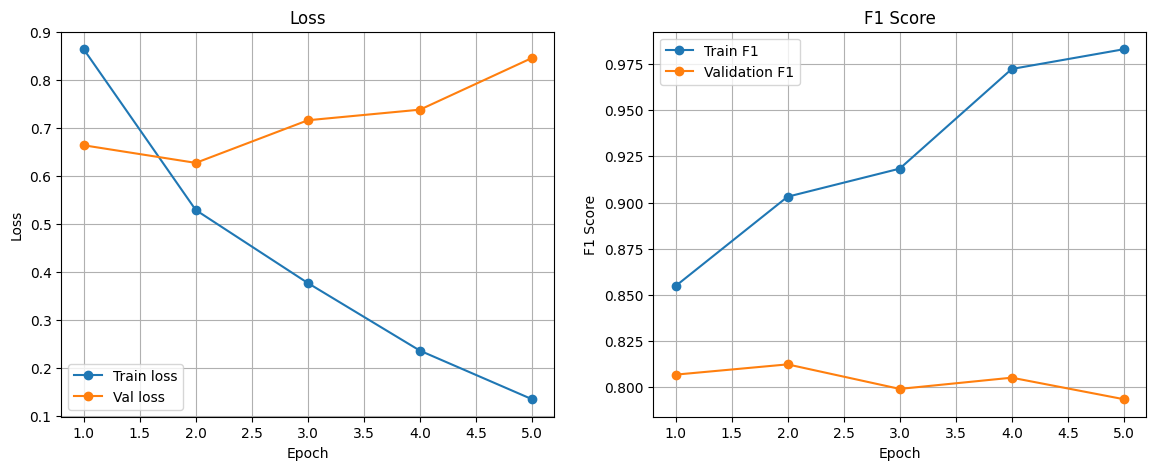

In [ ]:
trainer.plot_history()


Classification report:

                             precision    recall  f1-score   support

                    AI и ML       0.78      0.88      0.83       178
          Администрирование       0.78      0.84      0.81       148
                     Бэкенд       0.71      0.70      0.71       180
                    Геймдев       0.91      0.90      0.91        94
                     Дизайн       0.84      0.90      0.87        59
Информационная безопасность       0.82      0.84      0.83       147
        Маркетинг и контент       0.87      0.70      0.78        94
                 Менеджмент       0.78      0.72      0.75       154
                    Научпоп       0.84      0.90      0.87       165
                   Фронтенд       0.87      0.70      0.78       105

                   accuracy                           0.81      1324
                  macro avg       0.82      0.81      0.81      1324
               weighted avg       0.81      0.81      0.81      1324



<Figure size 1200x1200 with 0 Axes>

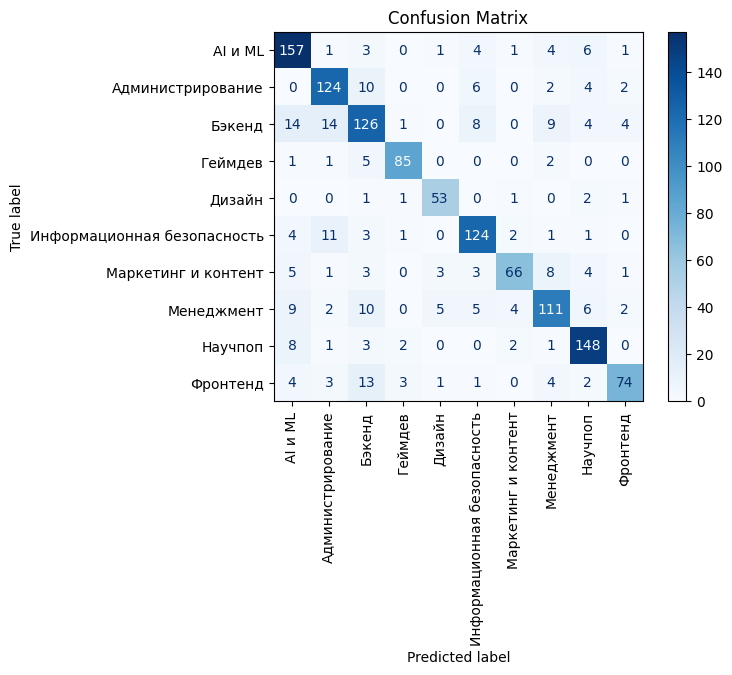

In [ ]:
trainer.classification_report()

## max_len = 384

In [ ]:
train_loader, val_loader = creating_dataloader(tokenizer, 16, 384)
optimizer = torch.optim.AdamW(model_bert.parameters(), lr=2e-5)

In [ ]:
trainer = Triner(
    model=model_bert,
    optimizer=optimizer,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    scheduler=None,
    label_names=label_names,
    save_path="best_model_BERT_384.pt"
)

trainer.fit(epochs=5)


Epoch 1/5


Computing train F1: 100%|██████████| 745/745 [04:31<00:00,  2.74it/s]


Train loss: 0.8982 | Val loss: 0.6784 | Accuracy: 0.7946 | Train F1: 0.8527 | Val F1: 0.8026
Best model saved

Epoch 2/5


Computing train F1: 100%|██████████| 745/745 [04:31<00:00,  2.74it/s]


Train loss: 0.5514 | Val loss: 0.6603 | Accuracy: 0.7968 | Train F1: 0.8866 | Val F1: 0.8039
Best model saved

Epoch 3/5


...

Train loss: 0.4017 | Val loss: 0.6714 | Accuracy: 0.7968 | Train F1: 0.9324 | Val F1: 0.8055
Best model saved

Epoch 4/5


Computing train F1: 100%|██████████| 745/745 [04:31<00:00,  2.74it/s]


Train loss: 0.2638 | Val loss: 0.7320 | Accuracy: 0.7938 | Train F1: 0.9624 | Val F1: 0.8007

Epoch 5/5


Computing train F1: 100%|██████████| 745/745 [04:31<00:00,  2.74it/s]


Train loss: 0.1637 | Val loss: 0.7947 | Accuracy: 0.7976 | Train F1: 0.9770 | Val F1: 0.8059
Best model saved

Training finished


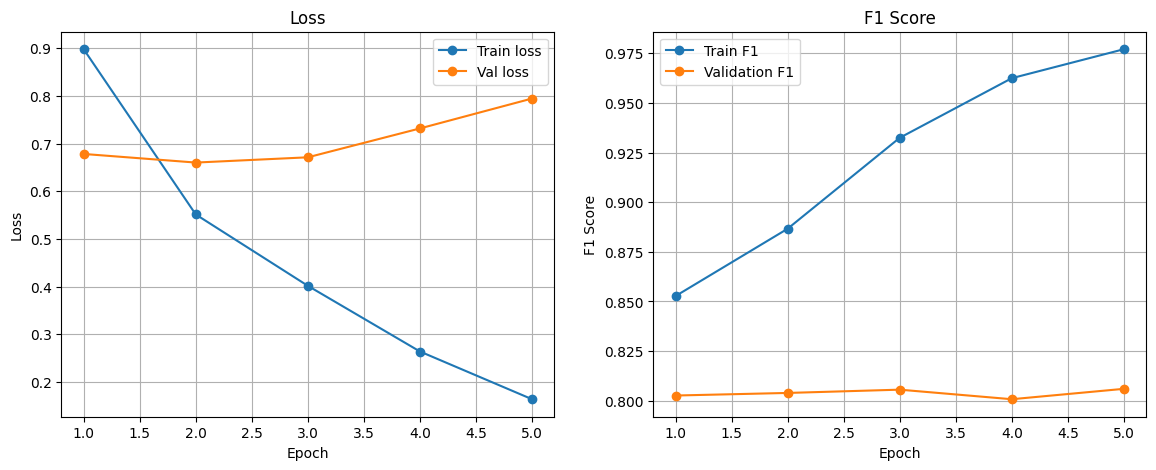

In [ ]:
trainer.plot_history()


Classification report:

                             precision    recall  f1-score   support

                    AI и ML       0.87      0.75      0.81       178
          Администрирование       0.77      0.82      0.79       148
                     Бэкенд       0.66      0.72      0.69       180
                    Геймдев       0.91      0.91      0.91        94
                     Дизайн       0.86      0.85      0.85        59
Информационная безопасность       0.88      0.77      0.82       147
        Маркетинг и контент       0.78      0.85      0.81        94
                 Менеджмент       0.77      0.73      0.75       154
                    Научпоп       0.86      0.91      0.88       165
                   Фронтенд       0.72      0.77      0.74       105

                   accuracy                           0.80      1324
                  macro avg       0.81      0.81      0.81      1324
               weighted avg       0.80      0.80      0.80      1324



<Figure size 1200x1200 with 0 Axes>

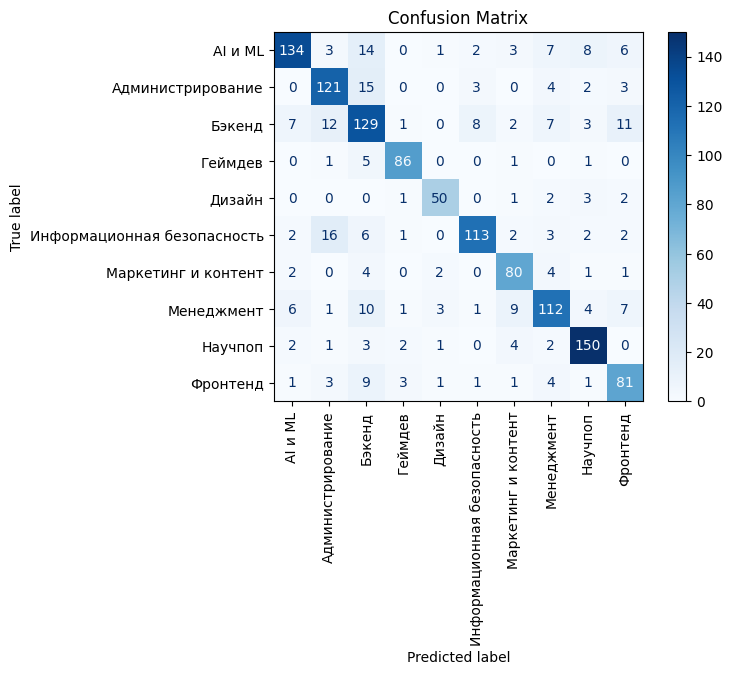

In [ ]:
trainer.classification_report()

## max_len = 512

In [ ]:
train_loader, val_loader = creating_dataloader(tokenizer, 16, 512)
optimizer = torch.optim.AdamW(model_bert.parameters(), lr=2e-5)

In [ ]:
trainer = Triner(
    model=model_bert,
    optimizer=optimizer,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    scheduler=None,
    label_names=label_names,
    save_path="best_model_BERT_512.pt"
)

trainer.fit(epochs=5)


Epoch 1/5


Computing train F1: 100%|██████████| 745/745 [06:12<00:00,  2.00it/s]


Train loss: 0.1213 | Val loss: 0.8298 | Accuracy: 0.8051 | Train F1: 0.9915 | Val F1: 0.8156
Best model saved

Epoch 2/5


Computing train F1: 100%|██████████| 745/745 [06:10<00:00,  2.01it/s]


Train loss: 0.0785 | Val loss: 0.9497 | Accuracy: 0.7908 | Train F1: 0.9919 | Val F1: 0.7998

Epoch 3/5


Computing train F1: 100%|██████████| 745/745 [06:10<00:00,  2.01it/s]


Train loss: 0.0589 | Val loss: 0.9678 | Accuracy: 0.7908 | Train F1: 0.9932 | Val F1: 0.7980

Epoch 4/5


Computing train F1: 100%|██████████| 745/745 [06:10<00:00,  2.01it/s]

Train loss: 0.0482 | Val loss: 1.0822 | Accuracy: 0.7847 | Train F1: 0.9958 | Val F1: 0.7938
Early stopping

Training finished


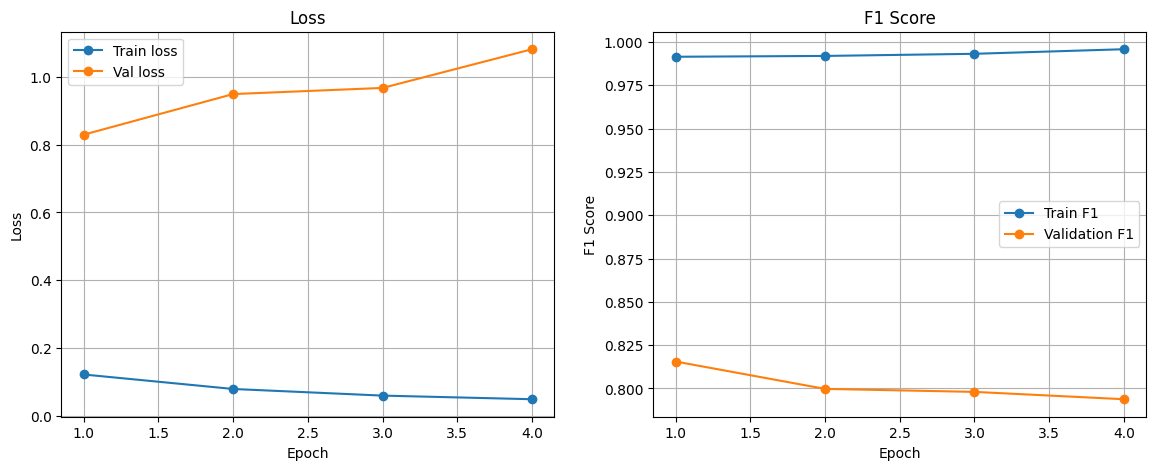

In [ ]:
trainer.plot_history()


Classification report:

                             precision    recall  f1-score   support

                    AI и ML       0.82      0.80      0.81       178
          Администрирование       0.76      0.82      0.79       148
                     Бэкенд       0.70      0.66      0.68       180
                    Геймдев       0.92      0.93      0.92        94
                     Дизайн       0.86      0.92      0.89        59
Информационная безопасность       0.84      0.82      0.83       147
        Маркетинг и контент       0.84      0.81      0.83        94
                 Менеджмент       0.79      0.76      0.77       154
                    Научпоп       0.84      0.88      0.86       165
                   Фронтенд       0.77      0.78      0.78       105

                   accuracy                           0.81      1324
                  macro avg       0.81      0.82      0.82      1324
               weighted avg       0.80      0.81      0.80      1324



<Figure size 1200x1200 with 0 Axes>

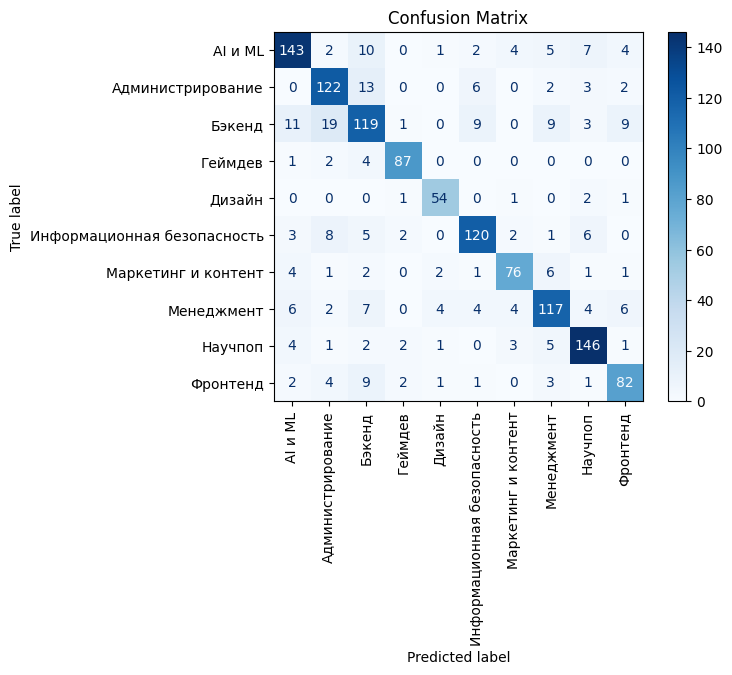

In [ ]:
trainer.classification_report()

## Batch size = 32

In [ ]:
train_loader, val_loader = creating_dataloader(tokenizer, 32)
optimizer = torch.optim.AdamW(model_bert.parameters(), lr=2e-5)

In [ ]:
trainer = Triner(
    model=model_bert,
    optimizer=optimizer,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    scheduler=None,
    label_names=label_names,
    save_path="best_model_BERT_b32.pt"
)

trainer.fit(epochs=5)


Epoch 1/5


Computing train F1: 100%|██████████| 373/373 [02:56<00:00,  2.11it/s]


Train loss: 0.0358 | Val loss: 1.0804 | Accuracy: 0.7855 | Train F1: 0.9979 | Val F1: 0.7928
Best model saved

Epoch 2/5


Computing train F1: 100%|██████████| 373/373 [02:56<00:00,  2.11it/s]


Train loss: 0.0237 | Val loss: 1.1600 | Accuracy: 0.7772 | Train F1: 0.9973 | Val F1: 0.7910

Epoch 3/5


...

Train loss: 0.0151 | Val loss: 1.2922 | Accuracy: 0.7772 | Train F1: 0.9974 | Val F1: 0.7853

Epoch 4/5


Computing train F1: 100%|██████████| 373/373 [02:56<00:00,  2.11it/s]


Train loss: 0.0243 | Val loss: 1.2014 | Accuracy: 0.7923 | Train F1: 0.9984 | Val F1: 0.8025
Best model saved

Epoch 5/5


Computing train F1: 100%|██████████| 373/373 [02:56<00:00,  2.11it/s]


Train loss: 0.0155 | Val loss: 1.2380 | Accuracy: 0.7938 | Train F1: 0.9995 | Val F1: 0.8034
Best model saved

Training finished


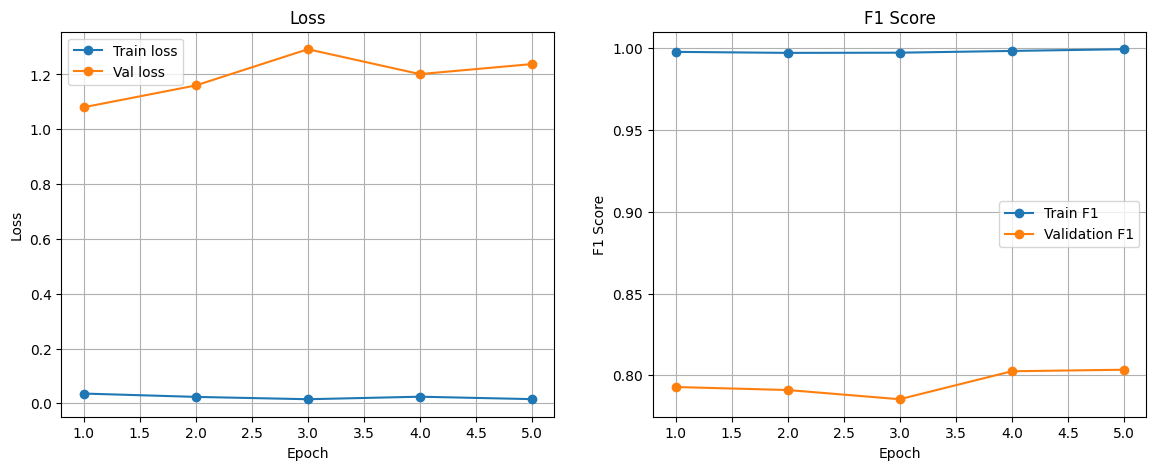

In [ ]:
trainer.plot_history()


Classification report:

                             precision    recall  f1-score   support

                    AI и ML       0.78      0.78      0.78       178
          Администрирование       0.79      0.77      0.78       148
                     Бэкенд       0.68      0.68      0.68       180
                    Геймдев       0.91      0.95      0.93        94
                     Дизайн       0.81      0.88      0.85        59
Информационная безопасность       0.80      0.89      0.85       147
        Маркетинг и контент       0.92      0.70      0.80        94
                 Менеджмент       0.75      0.73      0.74       154
                    Научпоп       0.82      0.87      0.84       165
                   Фронтенд       0.82      0.76      0.79       105

                   accuracy                           0.79      1324
                  macro avg       0.81      0.80      0.80      1324
               weighted avg       0.80      0.79      0.79      1324



<Figure size 1200x1200 with 0 Axes>

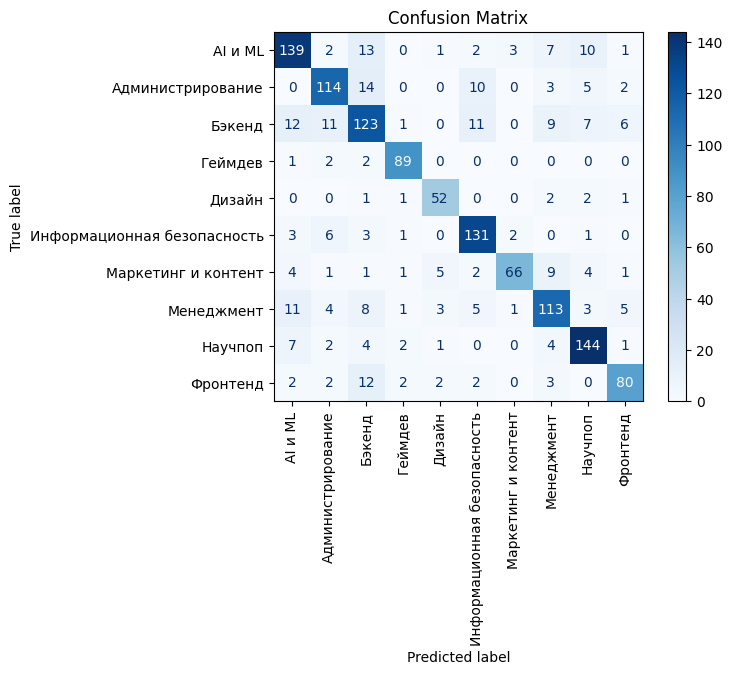

In [ ]:
trainer.classification_report()

## learning_rate = 3e-5, batch_size = 16, max_len = 512

In [ ]:
train_loader, val_loader = creating_dataloader(tokenizer, 16, 512)
optimizer = torch.optim.AdamW(model_bert.parameters(), lr=3e-5)

In [ ]:
trainer = Triner(
    model=model_bert,
    optimizer=optimizer,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    scheduler=None,
    label_names=label_names,
    save_path="best_model_BERT_last.pt"
)

trainer.fit(epochs=5)


Epoch 1/5


Computing train F1: 100%|██████████| 745/745 [06:02<00:00,  2.06it/s]


Train loss: 0.5671 | Val loss: 0.6079 | Accuracy: 0.8059 | Train F1: 0.8986 | Val F1: 0.8113
Best model saved

Epoch 2/5


Computing train F1: 100%|██████████| 745/745 [06:02<00:00,  2.05it/s]


Train loss: 0.4110 | Val loss: 0.6551 | Accuracy: 0.7931 | Train F1: 0.9295 | Val F1: 0.8016

Epoch 3/5


Computing train F1: 100%|██████████| 745/745 [06:02<00:00,  2.06it/s]


Train loss: 0.2547 | Val loss: 0.7233 | Accuracy: 0.7976 | Train F1: 0.9744 | Val F1: 0.7995

Epoch 4/5


Computing train F1: 100%|██████████| 745/745 [06:02<00:00,  2.06it/s]

Train loss: 0.1475 | Val loss: 0.8900 | Accuracy: 0.7825 | Train F1: 0.9793 | Val F1: 0.7918
Early stopping

Training finished


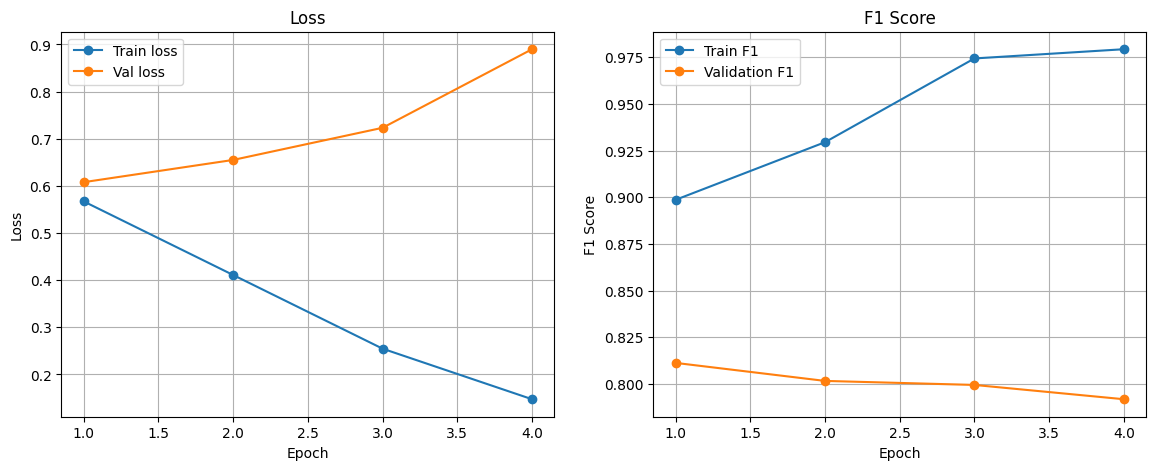

In [ ]:
trainer.plot_history()


Classification report:

                             precision    recall  f1-score   support

                    AI и ML       0.76      0.88      0.82       178
          Администрирование       0.80      0.76      0.78       148
                     Бэкенд       0.67      0.73      0.70       180
                    Геймдев       0.89      0.90      0.90        94
                     Дизайн       0.88      0.83      0.85        59
Информационная безопасность       0.83      0.90      0.86       147
        Маркетинг и контент       0.78      0.80      0.79        94
                 Менеджмент       0.84      0.72      0.78       154
                    Научпоп       0.92      0.85      0.88       165
                   Фронтенд       0.82      0.70      0.75       105

                   accuracy                           0.81      1324
                  macro avg       0.82      0.81      0.81      1324
               weighted avg       0.81      0.81      0.81      1324



<Figure size 1200x1200 with 0 Axes>

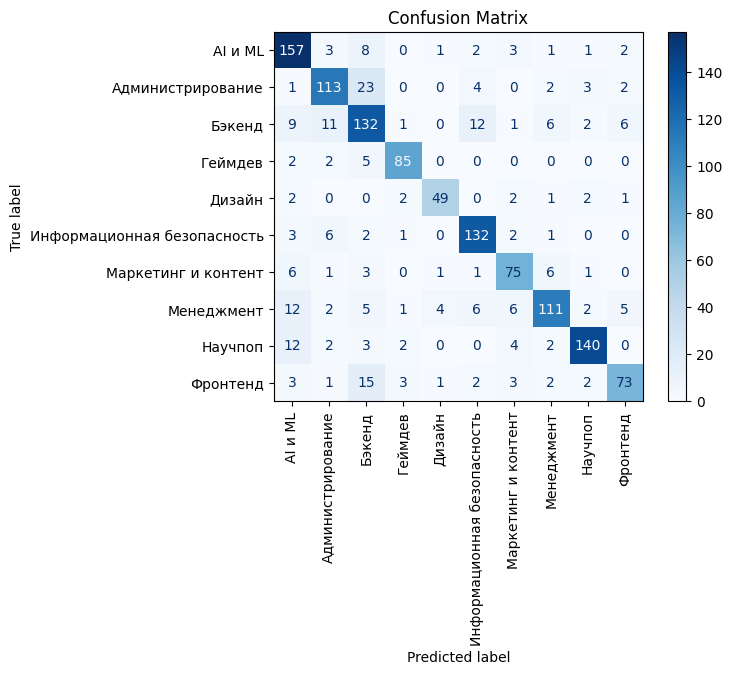

In [ ]:
trainer.classification_report()

# Tochka-AI/ruRoPEBert-classic-base-2k

In [ ]:
robert_model_name = "Tochka-AI/ruRoPEBert-classic-base-2k"
tokenizer = AutoTokenizer.from_pretrained(robert_model_name)

robert_model = AutoModelForSequenceClassification.from_pretrained(
    robert_model_name,
    num_labels=num_labels
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/965 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt:   0%|          | 0.00/1.78M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.71M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/695 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/712M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: Tochka-AI/ruRoPEBert-classic-base-2k
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.pooler.dense.bias                     | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.weight                          | MISSING    | 
bert.embeddings.position_embeddings.weight | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Co

## max_len = 256

In [ ]:
train_loader, val_loader = creating_dataloader(tokenizer, 16)
optimizer = torch.optim.AdamW(robert_model.parameters(), lr=2e-5)

In [ ]:
trainer = Triner(
    model=robert_model,
    optimizer=optimizer,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    scheduler=None,
    label_names=label_names,
    save_path="best_model_robert_256.pt"
)

trainer.fit(epochs=5)


Epoch 1/5


Computing train F1: 100%|██████████| 745/745 [03:24<00:00,  3.64it/s]


Train loss: 0.9706 | Val loss: 0.7780 | Accuracy: 0.7651 | Train F1: 0.8236 | Val F1: 0.7730
Best model saved

Epoch 2/5


Computing train F1: 100%|██████████| 745/745 [03:20<00:00,  3.72it/s]


Train loss: 0.6109 | Val loss: 0.7466 | Accuracy: 0.7719 | Train F1: 0.8636 | Val F1: 0.7704

Epoch 3/5


...

Train loss: 0.4515 | Val loss: 0.8451 | Accuracy: 0.7598 | Train F1: 0.8938 | Val F1: 0.7687

Epoch 4/5


Computing train F1: 100%|██████████| 745/745 [03:25<00:00,  3.62it/s]


Train loss: 0.3096 | Val loss: 0.8250 | Accuracy: 0.7764 | Train F1: 0.9588 | Val F1: 0.7820
Best model saved

Epoch 5/5


Computing train F1: 100%|██████████| 745/745 [03:27<00:00,  3.59it/s]

Train loss: 0.2049 | Val loss: 0.8900 | Accuracy: 0.7727 | Train F1: 0.9697 | Val F1: 0.7776

Training finished


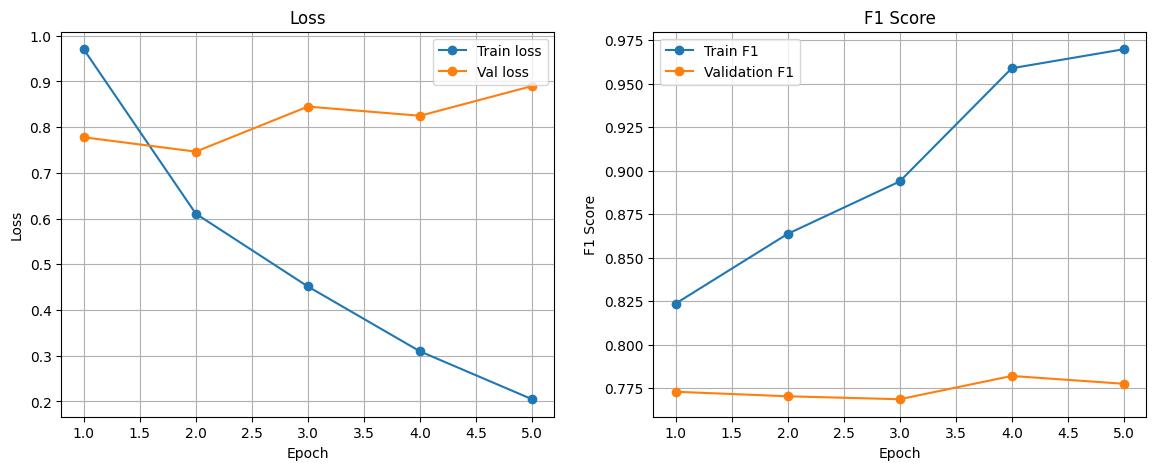

In [ ]:
trainer.plot_history()


Classification report:

                             precision    recall  f1-score   support

                    AI и ML       0.72      0.85      0.78       178
          Администрирование       0.82      0.72      0.77       148
                     Бэкенд       0.64      0.68      0.66       180
                    Геймдев       0.93      0.86      0.90        94
                     Дизайн       0.72      0.88      0.79        59
Информационная безопасность       0.81      0.89      0.85       147
        Маркетинг и контент       0.74      0.71      0.72        94
                 Менеджмент       0.81      0.64      0.72       154
                    Научпоп       0.85      0.84      0.84       165
                   Фронтенд       0.85      0.74      0.79       105

                   accuracy                           0.78      1324
                  macro avg       0.79      0.78      0.78      1324
               weighted avg       0.78      0.78      0.78      1324



<Figure size 1200x1200 with 0 Axes>

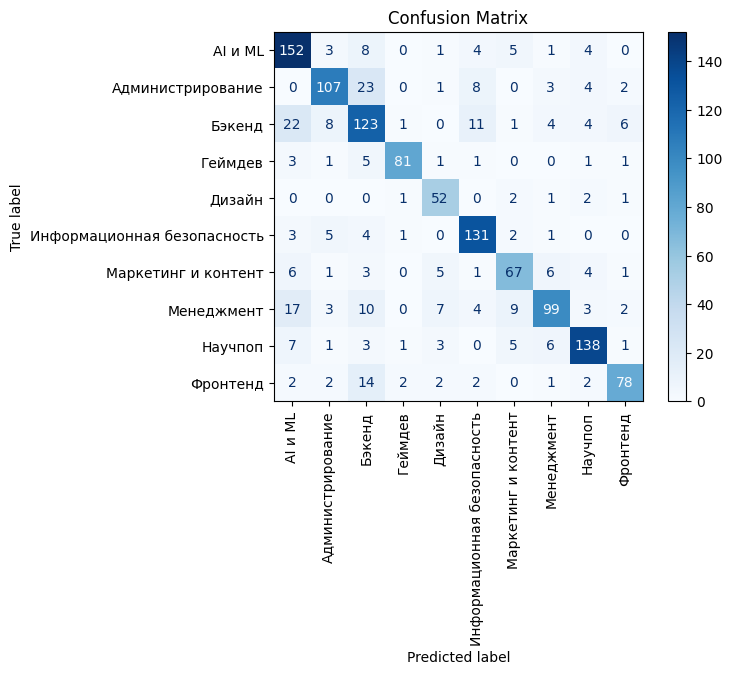

In [ ]:
trainer.classification_report()

## max_len = 384


In [ ]:
train_loader, val_loader = creating_dataloader(tokenizer, 16, 384)
optimizer = torch.optim.AdamW(robert_model.parameters(), lr=2e-5)

In [ ]:
trainer = Triner(
    model=robert_model,
    optimizer=optimizer,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    scheduler=None,
    label_names=label_names,
    save_path="best_model_robert_384.pt"
)

trainer.fit(epochs=5)


Epoch 1/5


Computing train F1: 100%|██████████| 745/745 [05:09<00:00,  2.40it/s]


Train loss: 0.9367 | Val loss: 0.7536 | Accuracy: 0.7817 | Train F1: 0.8235 | Val F1: 0.7863
Best model saved

Epoch 2/5


Computing train F1: 100%|██████████| 745/745 [05:11<00:00,  2.39it/s]


Train loss: 0.6176 | Val loss: 0.7187 | Accuracy: 0.7885 | Train F1: 0.8657 | Val F1: 0.7961
Best model saved

Epoch 3/5


...

Train loss: 0.4636 | Val loss: 0.7314 | Accuracy: 0.7847 | Train F1: 0.9171 | Val F1: 0.7896

Epoch 4/5


Computing train F1: 100%|██████████| 745/745 [05:10<00:00,  2.40it/s]


Train loss: 0.3269 | Val loss: 0.7673 | Accuracy: 0.7825 | Train F1: 0.9527 | Val F1: 0.7866

Epoch 5/5


Computing train F1: 100%|██████████| 745/745 [05:09<00:00,  2.41it/s]


Train loss: 0.2110 | Val loss: 0.7918 | Accuracy: 0.7931 | Train F1: 0.9790 | Val F1: 0.8049
Best model saved

Training finished


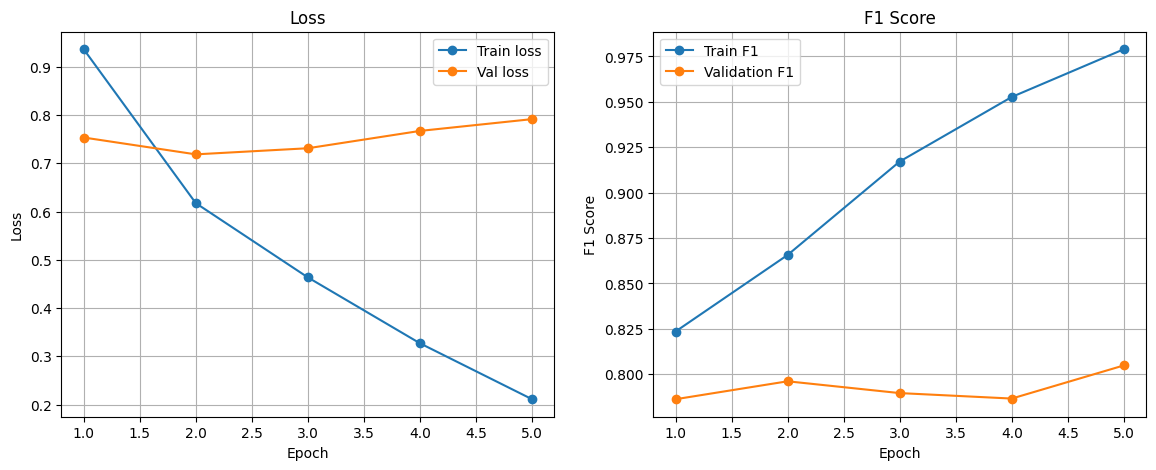

In [ ]:
trainer.plot_history()


Classification report:

                             precision    recall  f1-score   support

                    AI и ML       0.77      0.79      0.78       178
          Администрирование       0.76      0.84      0.80       148
                     Бэкенд       0.69      0.66      0.67       180
                    Геймдев       0.92      0.93      0.92        94
                     Дизайн       0.91      0.85      0.88        59
Информационная безопасность       0.85      0.84      0.85       147
        Маркетинг и контент       0.78      0.80      0.79        94
                 Менеджмент       0.75      0.75      0.75       154
                    Научпоп       0.87      0.81      0.84       165
                   Фронтенд       0.78      0.78      0.78       105

                   accuracy                           0.79      1324
                  macro avg       0.81      0.80      0.80      1324
               weighted avg       0.79      0.79      0.79      1324



<Figure size 1200x1200 with 0 Axes>

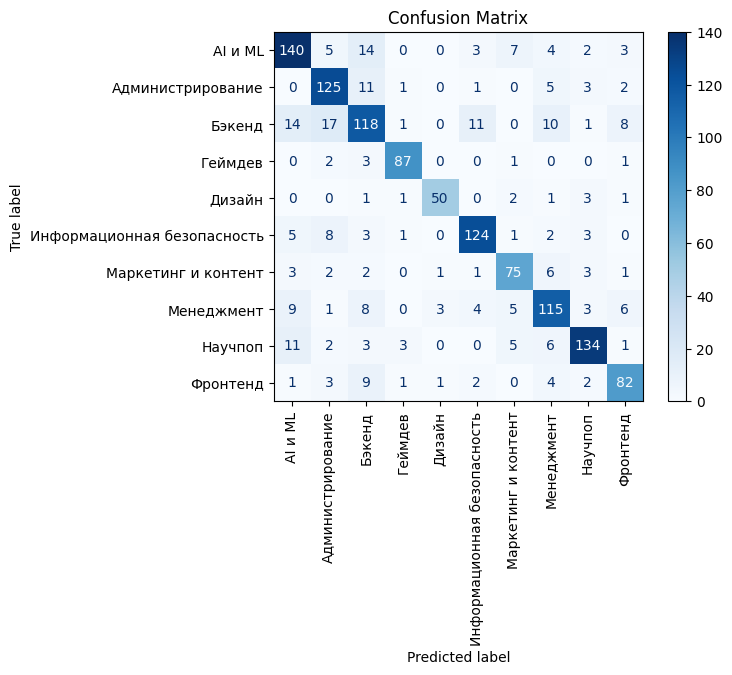

In [ ]:
trainer.classification_report()

## max_len = 512

In [ ]:
train_loader, val_loader = creating_dataloader(tokenizer, 16, 512)
optimizer = torch.optim.AdamW(robert_model.parameters(), lr=2e-5)

In [ ]:
trainer = Triner(
    model=robert_model,
    optimizer=optimizer,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    scheduler=None,
    label_names=label_names,
    save_path="best_model_robert_512.pt"
)

trainer.fit(epochs=5)



Epoch 1/5


Computing train F1: 100%|██████████| 745/745 [06:02<00:00,  2.06it/s]


Train loss: 0.9997 | Val loss: 0.8005 | Accuracy: 0.7659 | Train F1: 0.8038 | Val F1: 0.7715
Best model saved

Epoch 2/5


Computing train F1: 100%|██████████| 745/745 [06:02<00:00,  2.06it/s]


Train loss: 0.6294 | Val loss: 0.7254 | Accuracy: 0.7832 | Train F1: 0.8703 | Val F1: 0.7871
Best model saved

Epoch 3/5


...

Train loss: 0.4860 | Val loss: 0.7057 | Accuracy: 0.7968 | Train F1: 0.9107 | Val F1: 0.7989
Best model saved

Epoch 4/5


Computing train F1: 100%|██████████| 745/745 [06:02<00:00,  2.06it/s]


Train loss: 0.3476 | Val loss: 0.7965 | Accuracy: 0.7810 | Train F1: 0.9421 | Val F1: 0.7813

Epoch 5/5


Computing train F1: 100%|██████████| 745/745 [06:02<00:00,  2.06it/s]

Train loss: 0.2354 | Val loss: 0.8574 | Accuracy: 0.7742 | Train F1: 0.9635 | Val F1: 0.7787

Training finished


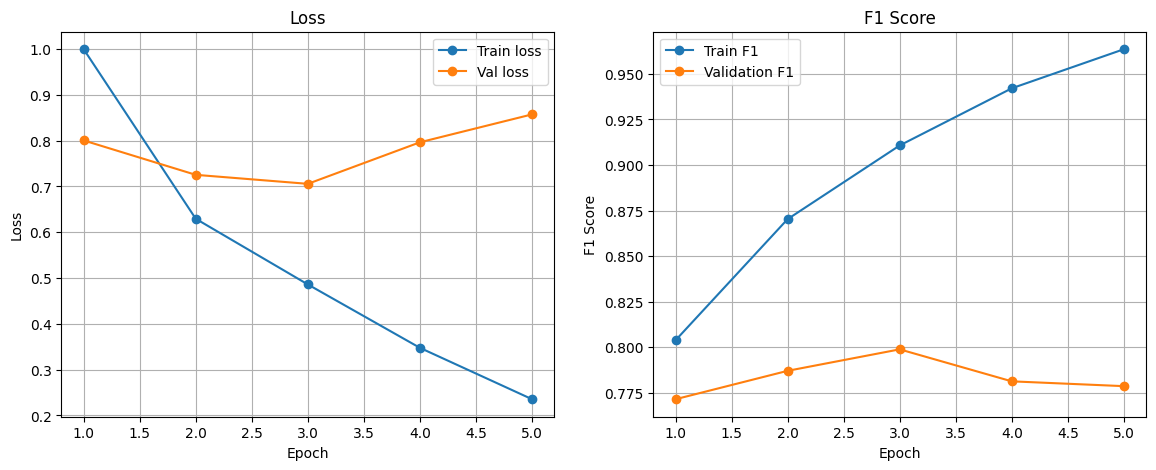

In [ ]:
trainer.plot_history()

## Batch size = 32


In [ ]:
train_loader, val_loader = creating_dataloader(tokenizer, 32)
optimizer = torch.optim.AdamW(robert_model.parameters(), lr=2e-5)

In [ ]:
trainer = Triner(
    model=robert_model,
    optimizer=optimizer,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    scheduler=None,
    label_names=label_names,
    save_path="best_model_robert_32.pt"
)

trainer.fit(epochs=5)


Epoch 1/5


Computing train F1: 100%|██████████| 373/373 [03:24<00:00,  1.82it/s]


Train loss: 0.1524 | Val loss: 0.9141 | Accuracy: 0.7787 | Train F1: 0.9855 | Val F1: 0.7877
Best model saved

Epoch 2/5


Computing train F1: 100%|██████████| 373/373 [03:20<00:00,  1.86it/s]


Train loss: 0.0714 | Val loss: 1.0744 | Accuracy: 0.7621 | Train F1: 0.9903 | Val F1: 0.7725

Epoch 3/5


Computing train F1: 100%|██████████| 373/373 [03:21<00:00,  1.86it/s]


Train loss: 0.0452 | Val loss: 1.0874 | Accuracy: 0.7757 | Train F1: 0.9947 | Val F1: 0.7813

Epoch 4/5


Computing train F1: 100%|██████████| 373/373 [03:15<00:00,  1.90it/s]


Train loss: 0.0385 | Val loss: 1.1225 | Accuracy: 0.7727 | Train F1: 0.9969 | Val F1: 0.7832
Early stopping

Training finished


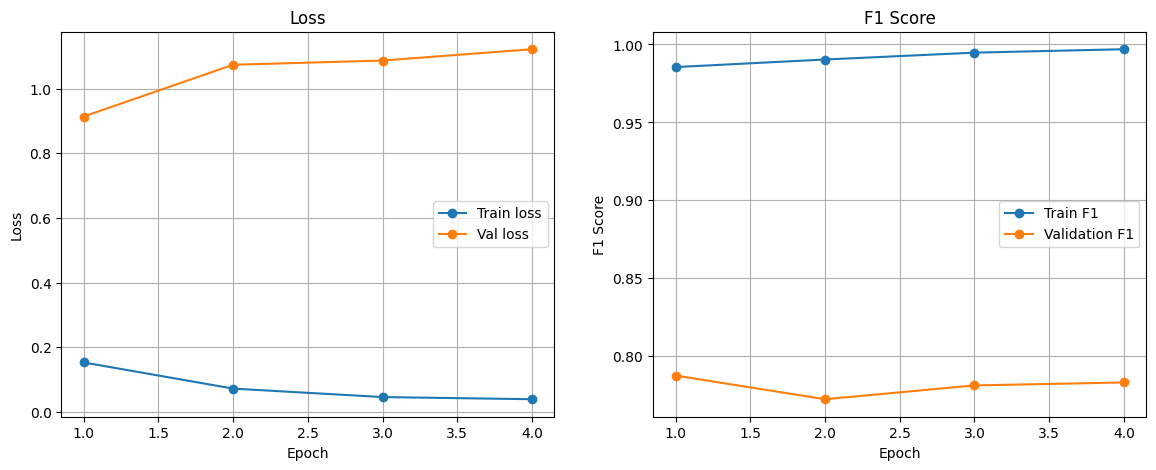

In [ ]:
trainer.plot_history()


Classification report:

                             precision    recall  f1-score   support

                    AI и ML       0.76      0.76      0.76       178
          Администрирование       0.79      0.80      0.79       148
                     Бэкенд       0.61      0.73      0.66       180
                    Геймдев       0.84      0.90      0.87        94
                     Дизайн       0.86      0.81      0.83        59
Информационная безопасность       0.87      0.86      0.87       147
        Маркетинг и контент       0.82      0.70      0.76        94
                 Менеджмент       0.75      0.71      0.73       154
                    Научпоп       0.91      0.79      0.85       165
                   Фронтенд       0.73      0.77      0.75       105

                   accuracy                           0.78      1324
                  macro avg       0.79      0.78      0.79      1324
               weighted avg       0.79      0.78      0.78      1324



<Figure size 1200x1200 with 0 Axes>

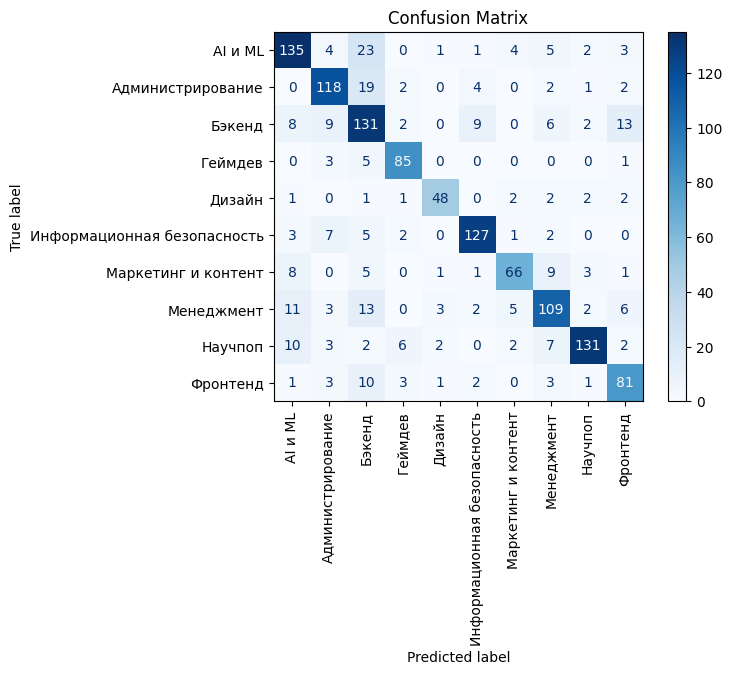

In [ ]:
trainer.classification_report()

## learning_rate = 3e-5, batch_size = 16, max_len = 512

In [ ]:
train_loader, val_loader = creating_dataloader(tokenizer, 16, 512)
optimizer = torch.optim.AdamW(robert_model.parameters(), lr=3e-5)

In [ ]:
trainer = Triner(
    model=robert_model,
    optimizer=optimizer,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    scheduler=None,
    label_names=label_names,
    save_path="best_model_robert_last.pt"
)

trainer.fit(epochs=5)


Epoch 1/5


Computing train F1: 100%|██████████| 745/745 [06:00<00:00,  2.07it/s]


Train loss: 0.9630 | Val loss: 0.8493 | Accuracy: 0.7508 | Train F1: 0.7933 | Val F1: 0.7529
Best model saved

Epoch 2/5


Computing train F1: 100%|██████████| 745/745 [06:02<00:00,  2.06it/s]


Train loss: 0.6217 | Val loss: 0.7360 | Accuracy: 0.7817 | Train F1: 0.8713 | Val F1: 0.7848
Best model saved

Epoch 3/5


...

Train loss: 0.4495 | Val loss: 0.7240 | Accuracy: 0.7885 | Train F1: 0.9178 | Val F1: 0.7928
Best model saved

Epoch 4/5


Computing train F1: 100%|██████████| 745/745 [06:01<00:00,  2.06it/s]


Train loss: 0.3069 | Val loss: 0.8438 | Accuracy: 0.7817 | Train F1: 0.9585 | Val F1: 0.7833

Epoch 5/5


Computing train F1: 100%|██████████| 745/745 [05:59<00:00,  2.07it/s]

Train loss: 0.1734 | Val loss: 0.9061 | Accuracy: 0.7779 | Train F1: 0.9818 | Val F1: 0.7835

Training finished


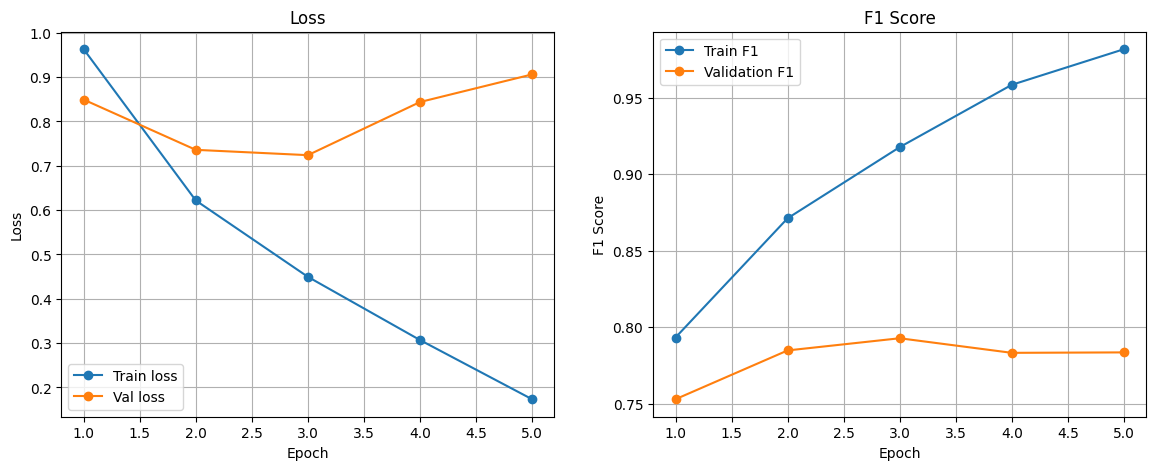

In [ ]:
trainer.plot_history()


Classification report:

                             precision    recall  f1-score   support

                    AI и ML       0.73      0.87      0.79       178
          Администрирование       0.81      0.76      0.79       148
                     Бэкенд       0.65      0.71      0.68       180
                    Геймдев       0.86      0.91      0.89        94
                     Дизайн       0.88      0.75      0.81        59
Информационная безопасность       0.89      0.76      0.82       147
        Маркетинг и контент       0.85      0.66      0.74        94
                 Менеджмент       0.73      0.78      0.75       154
                    Научпоп       0.90      0.88      0.89       165
                   Фронтенд       0.77      0.77      0.77       105

                   accuracy                           0.79      1324
                  macro avg       0.81      0.78      0.79      1324
               weighted avg       0.80      0.79      0.79      1324



<Figure size 1200x1200 with 0 Axes>

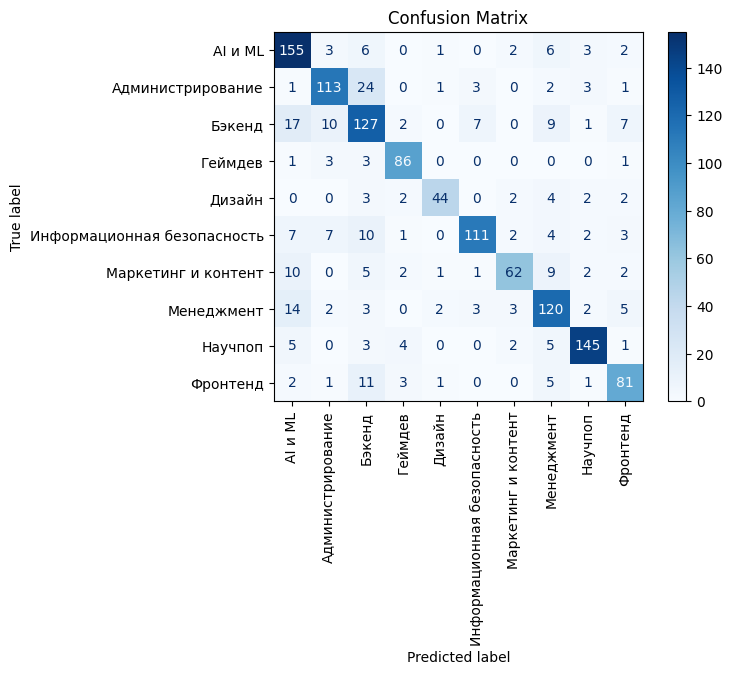

In [ ]:
trainer.classification_report()

# deepvk/RuModernBERT-base

In [ ]:
robert_model_name = "deepvk/RuModernBERT-base"
tokenizer = AutoTokenizer.from_pretrained(robert_model_name)

ru_modern_bert_model = AutoModelForSequenceClassification.from_pretrained(
    robert_model_name,
    num_labels=num_labels
)

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/837 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/599M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

ModernBertForSequenceClassification LOAD REPORT from: deepvk/RuModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.bias   | MISSING    | 
classifier.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## max_len = 256

In [ ]:
train_loader, val_loader = creating_dataloader(tokenizer, 16)
optimizer = torch.optim.AdamW(ru_modern_bert_model.parameters(), lr=2e-5)

In [ ]:
trainer = Triner(
    model=ru_modern_bert_model,
    optimizer=optimizer,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    scheduler=None,
    label_names=label_names,
    save_path="best_model_ru_modern_bert_256.pt"
)

trainer.fit(epochs=5)


Epoch 1/5


Computing train F1: 100%|██████████| 745/745 [03:37<00:00,  3.42it/s]


Train loss: 0.8118 | Val loss: 0.6439 | Accuracy: 0.7908 | Train F1: 0.8608 | Val F1: 0.7946
Best model saved

Epoch 2/5


Computing train F1: 100%|██████████| 745/745 [03:31<00:00,  3.52it/s]


Train loss: 0.4241 | Val loss: 0.6580 | Accuracy: 0.7968 | Train F1: 0.9340 | Val F1: 0.8002
Best model saved

Epoch 3/5


...

Train loss: 0.1842 | Val loss: 0.6887 | Accuracy: 0.8014 | Train F1: 0.9872 | Val F1: 0.8058
Best model saved

Epoch 4/5


Computing train F1: 100%|██████████| 745/745 [03:34<00:00,  3.47it/s]


Train loss: 0.0546 | Val loss: 1.1894 | Accuracy: 0.7825 | Train F1: 0.9837 | Val F1: 0.7912

Epoch 5/5


Computing train F1: 100%|██████████| 745/745 [03:37<00:00,  3.42it/s]


Train loss: 0.0308 | Val loss: 1.1984 | Accuracy: 0.7915 | Train F1: 0.9935 | Val F1: 0.8042

Training finished


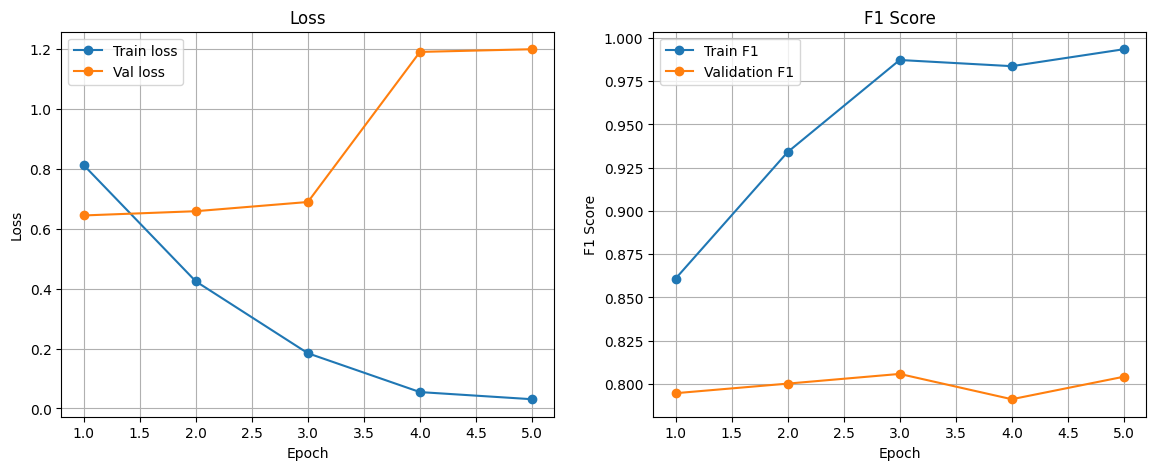

In [ ]:
trainer.plot_history()


Classification report:

                             precision    recall  f1-score   support

                    AI и ML       0.78      0.87      0.82       178
          Администрирование       0.82      0.77      0.79       148
                     Бэкенд       0.67      0.73      0.70       180
                    Геймдев       0.89      0.95      0.92        94
                     Дизайн       0.86      0.81      0.83        59
Информационная безопасность       0.90      0.84      0.87       147
        Маркетинг и контент       0.78      0.69      0.73        94
                 Менеджмент       0.76      0.79      0.77       154
                    Научпоп       0.92      0.80      0.86       165
                   Фронтенд       0.74      0.77      0.75       105

                   accuracy                           0.80      1324
                  macro avg       0.81      0.80      0.81      1324
               weighted avg       0.81      0.80      0.80      1324



<Figure size 1200x1200 with 0 Axes>

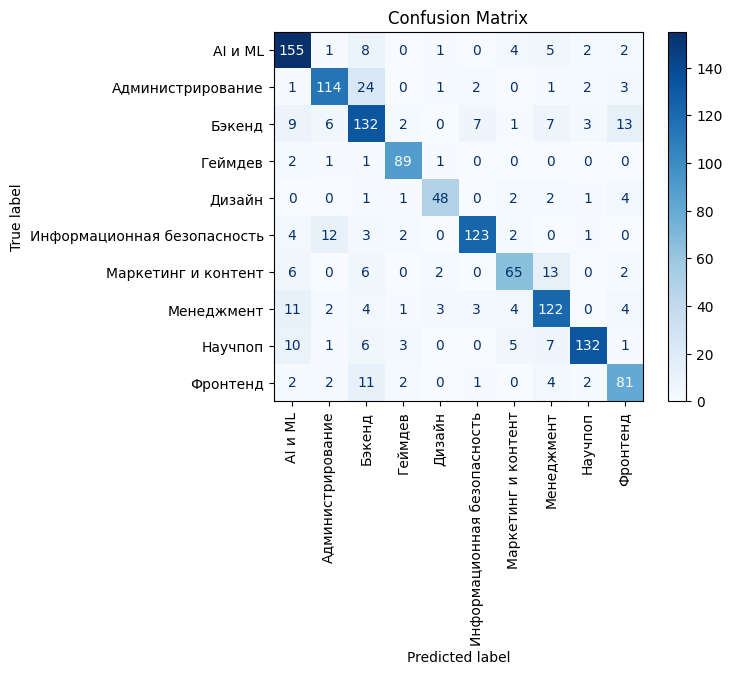

In [ ]:
trainer.classification_report()

## Max_len = 384

In [ ]:
train_loader, val_loader = creating_dataloader(tokenizer, 16, 384)
optimizer = torch.optim.AdamW(ru_modern_bert_model.parameters(), lr=2e-5)

In [ ]:
trainer = Triner(
    model=ru_modern_bert_model,
    optimizer=optimizer,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    scheduler=None,
    label_names=label_names,
    save_path="best_model_ru_modern_bert_384.pt"
)

trainer.fit(epochs=5)


Epoch 1/5


Computing train F1: 100%|██████████| 745/745 [06:52<00:00,  1.81it/s]


Train loss: 0.8192 | Val loss: 0.6039 | Accuracy: 0.8127 | Train F1: 0.8698 | Val F1: 0.8190
Best model saved

Epoch 2/5


Computing train F1: 100%|██████████| 745/745 [06:51<00:00,  1.81it/s]


Train loss: 0.4337 | Val loss: 0.5828 | Accuracy: 0.8301 | Train F1: 0.9394 | Val F1: 0.8334
Best model saved

Epoch 3/5


...

Train loss: 0.2258 | Val loss: 0.7458 | Accuracy: 0.8074 | Train F1: 0.9770 | Val F1: 0.8138

Epoch 4/5


Computing train F1: 100%|██████████| 745/745 [06:52<00:00,  1.81it/s]


Train loss: 0.0899 | Val loss: 0.7758 | Accuracy: 0.8112 | Train F1: 0.9892 | Val F1: 0.8163

Epoch 5/5


Computing train F1: 100%|██████████| 745/745 [06:52<00:00,  1.81it/s]

Train loss: 0.0431 | Val loss: 0.9321 | Accuracy: 0.8082 | Train F1: 0.9939 | Val F1: 0.8141
Early stopping

Training finished


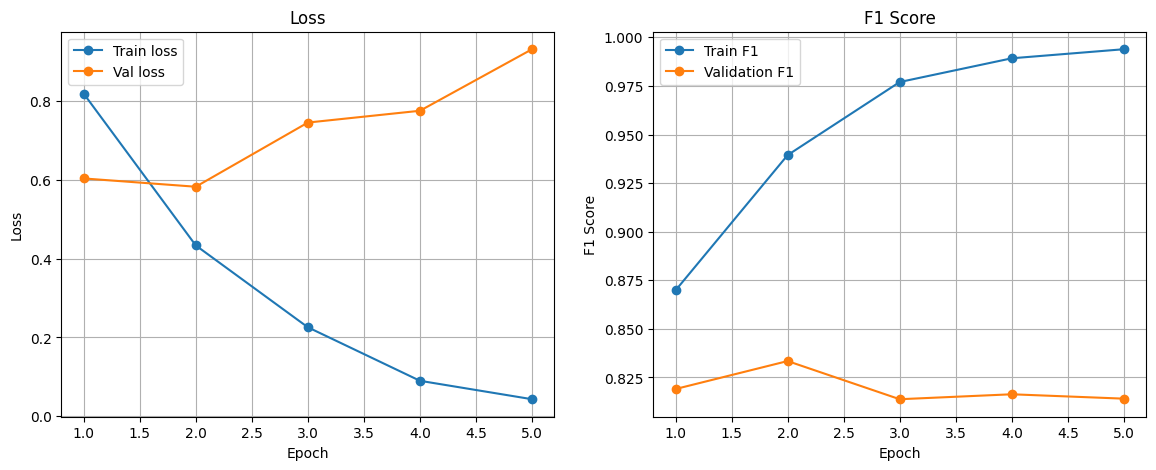

In [ ]:
trainer.plot_history()


Classification report:

                             precision    recall  f1-score   support

                    AI и ML       0.80      0.88      0.84       178
          Администрирование       0.79      0.86      0.82       148
                     Бэкенд       0.83      0.70      0.76       180
                    Геймдев       0.91      0.96      0.93        94
                     Дизайн       0.78      0.90      0.83        59
Информационная безопасность       0.86      0.88      0.87       147
        Маркетинг и контент       0.87      0.76      0.81        94
                 Менеджмент       0.76      0.80      0.78       154
                    Научпоп       0.90      0.84      0.87       165
                   Фронтенд       0.86      0.79      0.82       105

                   accuracy                           0.83      1324
                  macro avg       0.83      0.84      0.83      1324
               weighted avg       0.83      0.83      0.83      1324



<Figure size 1200x1200 with 0 Axes>

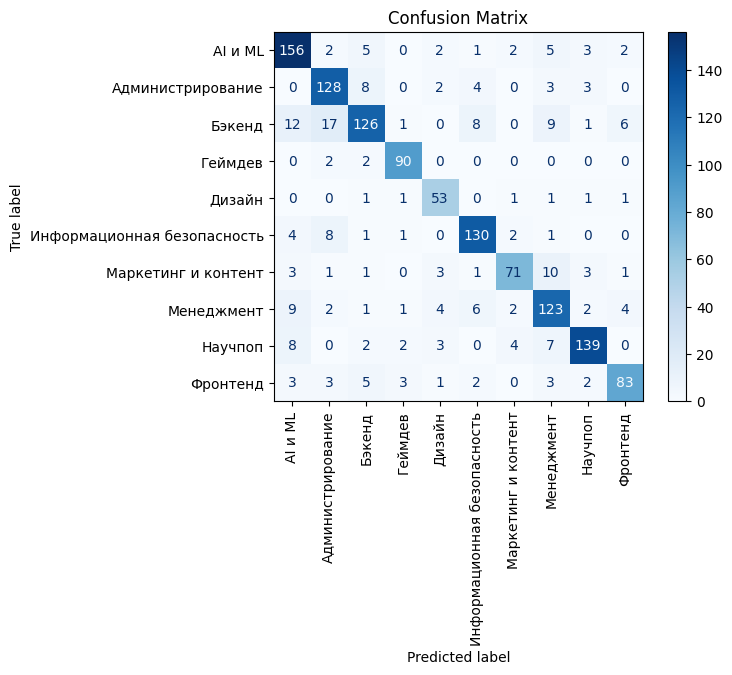

In [ ]:
trainer.classification_report()

## Max_len = 512

In [ ]:
train_loader, val_loader = creating_dataloader(tokenizer, 16, 512)
optimizer = torch.optim.AdamW(ru_modern_bert_model.parameters(), lr=2e-5)

In [ ]:
trainer = Triner(
    model=ru_modern_bert_model,
    optimizer=optimizer,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    scheduler=None,
    label_names=label_names,
    save_path="best_model_ru_modern_bert_512.pt"
)

trainer.fit(epochs=5)


Epoch 1/5


Computing train F1: 100%|██████████| 745/745 [09:55<00:00,  1.25it/s]


Train loss: 0.6192 | Val loss: 0.5789 | Accuracy: 0.8165 | Train F1: 0.8924 | Val F1: 0.8211
Best model saved

Epoch 2/5


Computing train F1: 100%|██████████| 745/745 [09:52<00:00,  1.26it/s]


Train loss: 0.3129 | Val loss: 0.6269 | Accuracy: 0.8225 | Train F1: 0.9521 | Val F1: 0.8287
Best model saved

Epoch 3/5


...

Train loss: 0.1349 | Val loss: 0.6025 | Accuracy: 0.8316 | Train F1: 0.9871 | Val F1: 0.8377
Best model saved

Epoch 4/5


Computing train F1: 100%|██████████| 745/745 [09:52<00:00,  1.26it/s]


Train loss: 0.0646 | Val loss: 0.7633 | Accuracy: 0.8180 | Train F1: 0.9865 | Val F1: 0.8238

Epoch 5/5


Computing train F1: 100%|██████████| 745/745 [09:54<00:00,  1.25it/s]

Train loss: 0.0477 | Val loss: 0.9462 | Accuracy: 0.8195 | Train F1: 0.9973 | Val F1: 0.8246

Training finished


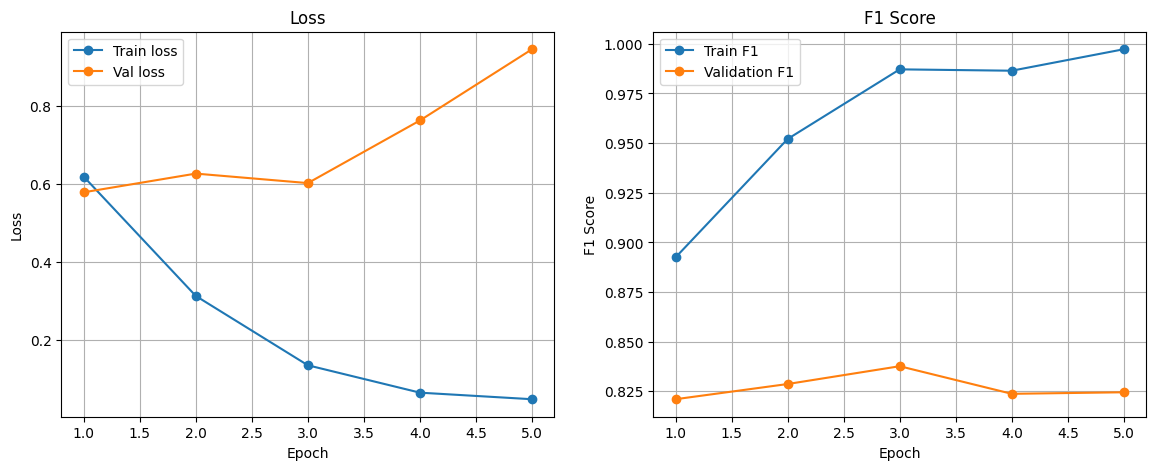

In [ ]:
trainer.plot_history()


Classification report:

                             precision    recall  f1-score   support

                    AI и ML       0.81      0.84      0.83       178
          Администрирование       0.86      0.84      0.85       148
                     Бэкенд       0.77      0.76      0.76       180
                    Геймдев       0.91      0.96      0.93        94
                     Дизайн       0.90      0.88      0.89        59
Информационная безопасность       0.87      0.89      0.88       147
        Маркетинг и контент       0.82      0.77      0.79        94
                 Менеджмент       0.77      0.77      0.77       154
                    Научпоп       0.92      0.84      0.88       165
                   Фронтенд       0.75      0.85      0.80       105

                   accuracy                           0.83      1324
                  macro avg       0.84      0.84      0.84      1324
               weighted avg       0.83      0.83      0.83      1324



<Figure size 1200x1200 with 0 Axes>

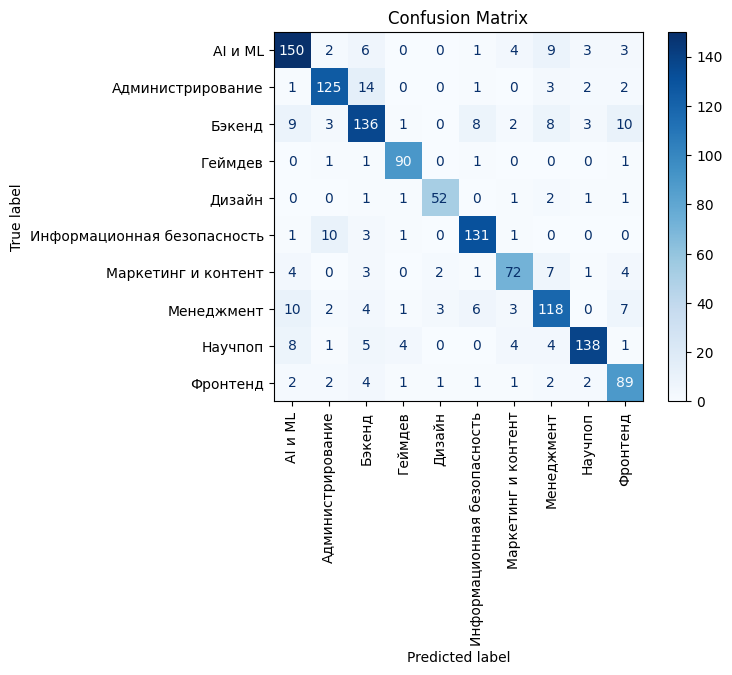

In [ ]:
trainer.classification_report()

## Batch size 32

In [ ]:
train_loader, val_loader = creating_dataloader(tokenizer, 32)
optimizer = torch.optim.AdamW(ru_modern_bert_model.parameters(), lr=2e-5)

In [ ]:
trainer = Triner(
    model=ru_modern_bert_model,
    optimizer=optimizer,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    scheduler=None,
    label_names=label_names,
    save_path="best_model_ru_modern_bert_32.pt"
)

trainer.fit(epochs=5)


Epoch 1/5


Computing train F1: 100%|██████████| 373/373 [03:52<00:00,  1.60it/s]


Train loss: 0.1108 | Val loss: 0.9243 | Accuracy: 0.7976 | Train F1: 0.9909 | Val F1: 0.8023
Best model saved

Epoch 2/5


Computing train F1: 100%|██████████| 373/373 [03:28<00:00,  1.79it/s]


Train loss: 0.0697 | Val loss: 1.0980 | Accuracy: 0.7674 | Train F1: 0.9933 | Val F1: 0.7776

Epoch 3/5


Computing train F1: 100%|██████████| 373/373 [03:30<00:00,  1.77it/s]


Train loss: 0.0456 | Val loss: 1.1242 | Accuracy: 0.7802 | Train F1: 0.9953 | Val F1: 0.7889

Epoch 4/5


Computing train F1: 100%|██████████| 373/373 [03:26<00:00,  1.80it/s]


Train loss: 0.0337 | Val loss: 1.1113 | Accuracy: 0.7878 | Train F1: 0.9981 | Val F1: 0.7929
Early stopping

Training finished


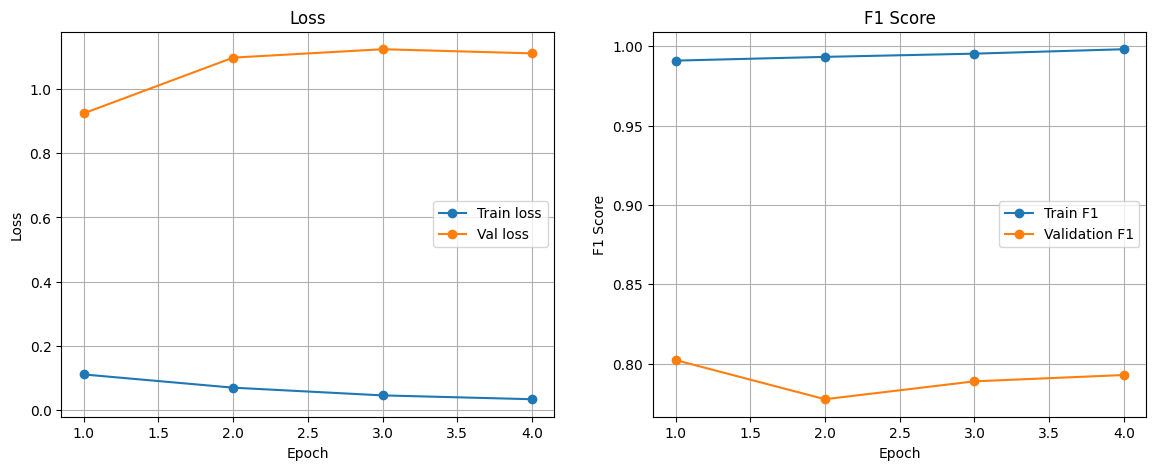

In [ ]:
trainer.plot_history()


Classification report:

                             precision    recall  f1-score   support

                    AI и ML       0.81      0.83      0.82       178
          Администрирование       0.71      0.84      0.77       148
                     Бэкенд       0.73      0.63      0.68       180
                    Геймдев       0.94      0.88      0.91        94
                     Дизайн       0.76      0.85      0.80        59
Информационная безопасность       0.85      0.86      0.86       147
        Маркетинг и контент       0.78      0.81      0.80        94
                 Менеджмент       0.79      0.75      0.77       154
                    Научпоп       0.86      0.84      0.85       165
                   Фронтенд       0.78      0.76      0.77       105

                   accuracy                           0.80      1324
                  macro avg       0.80      0.81      0.80      1324
               weighted avg       0.80      0.80      0.80      1324



<Figure size 1200x1200 with 0 Axes>

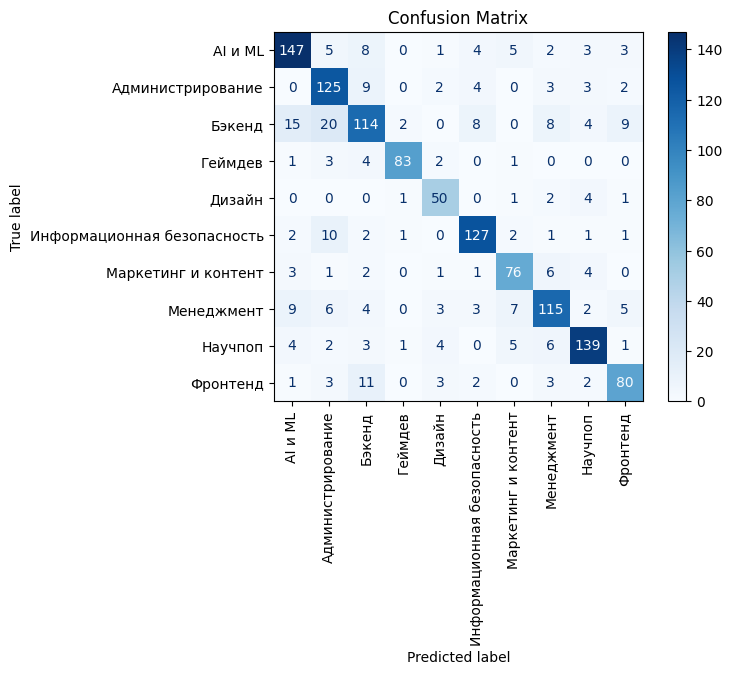

In [ ]:
trainer.classification_report()

## learning_rate = 3e-5, batch_size = 16, max_len = 512

In [ ]:
train_loader, val_loader = creating_dataloader(tokenizer, 16, 512)
optimizer = torch.optim.AdamW(ru_modern_bert_model.parameters(), lr=3e-5)

In [ ]:
trainer = Triner(
    model=ru_modern_bert_model,
    optimizer=optimizer,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    scheduler=None,
    label_names=label_names,
    save_path="best_model_ru_modern_bert_last.pt"
)

trainer.fit(epochs=5)


Epoch 1/5


Computing train F1: 100%|██████████| 745/745 [10:23<00:00,  1.19it/s]


Train loss: 0.7430 | Val loss: 0.5960 | Accuracy: 0.8066 | Train F1: 0.8761 | Val F1: 0.8124
Best model saved

Epoch 2/5


Computing train F1: 100%|██████████| 745/745 [10:23<00:00,  1.20it/s]


Train loss: 0.4292 | Val loss: 0.6348 | Accuracy: 0.7953 | Train F1: 0.9299 | Val F1: 0.8033

Epoch 3/5


...

Train loss: 0.2078 | Val loss: 0.7186 | Accuracy: 0.8112 | Train F1: 0.9747 | Val F1: 0.8184
Best model saved

Epoch 4/5


Computing train F1: 100%|██████████| 745/745 [10:21<00:00,  1.20it/s]


Train loss: 0.0856 | Val loss: 0.8776 | Accuracy: 0.8029 | Train F1: 0.9883 | Val F1: 0.8090

Epoch 5/5


Computing train F1: 100%|██████████| 745/745 [10:07<00:00,  1.23it/s]

Train loss: 0.0403 | Val loss: 1.1867 | Accuracy: 0.8029 | Train F1: 0.9871 | Val F1: 0.8097

Training finished


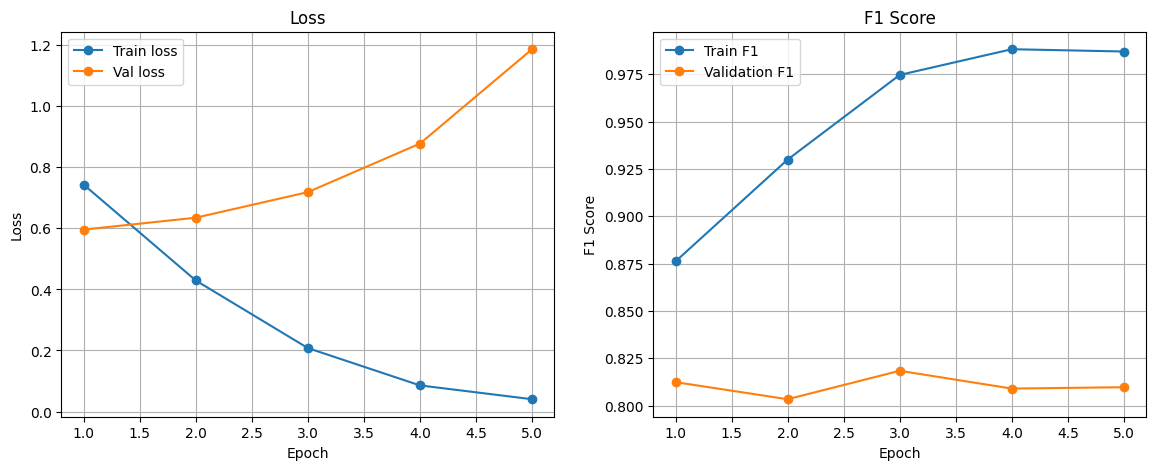

In [ ]:
trainer.plot_history()


Classification report:

                             precision    recall  f1-score   support

                    AI и ML       0.87      0.80      0.83       178
          Администрирование       0.82      0.74      0.78       148
                     Бэкенд       0.72      0.71      0.71       180
                    Геймдев       0.90      0.91      0.91        94
                     Дизайн       0.86      0.85      0.85        59
Информационная безопасность       0.79      0.95      0.86       147
        Маркетинг и контент       0.92      0.73      0.82        94
                 Менеджмент       0.68      0.83      0.75       154
                    Научпоп       0.90      0.86      0.88       165
                   Фронтенд       0.83      0.76      0.80       105

                   accuracy                           0.81      1324
                  macro avg       0.83      0.81      0.82      1324
               weighted avg       0.82      0.81      0.81      1324



<Figure size 1200x1200 with 0 Axes>

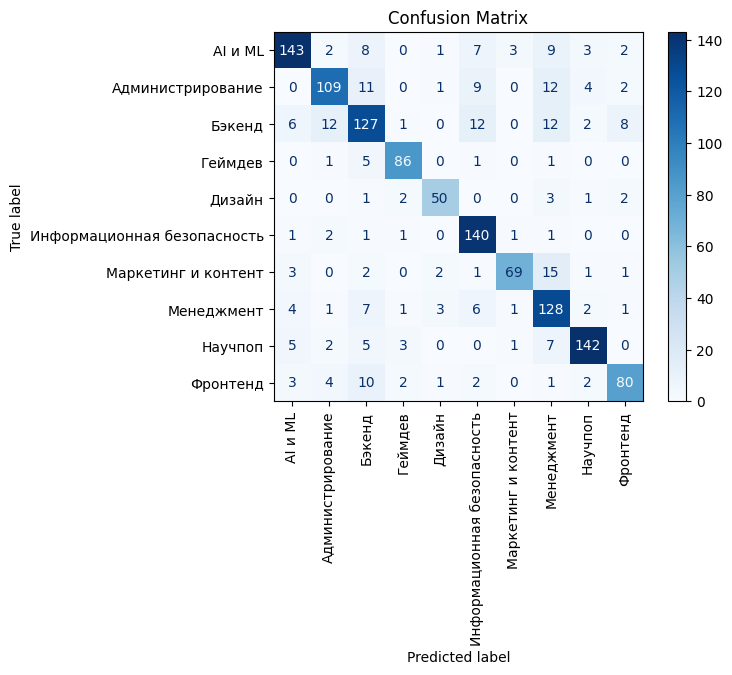

In [ ]:
trainer.classification_report()